# Imports

In [50]:
!pip install -qU wandb

import os, glob, json
from pathlib import Path
import random
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score, classification_report

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split, Subset

import torchvision.models as models

import pytorch_lightning as L
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping, LearningRateMonitor
from pytorch_lightning.loggers import WandbLogger

import wandb
import kagglehub

import warnings
warnings.filterwarnings("ignore")

SEED=42
random.seed(SEED)
np.random.seed(SEED)

print(f"PyTorch  : {torch.__version__}")
print(f"Lightning: {L.__version__}")
print(f"CUDA     : {torch.cuda.is_available()} | GPUs: {torch.cuda.device_count()}")

PyTorch  : 2.8.0+cu126
Lightning: 2.6.0
CUDA     : False | GPUs: 0


# Loading Data

In [2]:
DATA_DIR = "/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup"

GENRES_DIR = os.path.join(DATA_DIR, "genres_stems")
NOISE_DIR = os.path.join(DATA_DIR, "ESC-50-master", "audio")
MASHUP_DIR = os.path.join(DATA_DIR, "mashups")

GENRES = sorted(os.listdir(GENRES_DIR))
GENRES

['blues',
 'classical',
 'country',
 'disco',
 'hiphop',
 'jazz',
 'metal',
 'pop',
 'reggae',
 'rock']

In [3]:
rows = []

for genre in GENRES:
    genre_path = os.path.join(GENRES_DIR, genre)

    for folder in os.listdir(genre_path):
        folder_path = os.path.join(genre_path, folder)

        row = {
            "genre": genre,
            "folder": folder,
            "drums": os.path.join(folder_path, "drums.wav"),
            "bass": os.path.join(folder_path, "bass.wav"),
            "vocals": os.path.join(folder_path, "vocals.wav"),
            "other": os.path.join(folder_path, "other.wav"),
        }

        rows.append(row)

train_df = pd.DataFrame(rows)

print("Total Samples: ", len(train_df))
train_df.head()

Total Samples:  1000


,genre,folder,drums,bass,vocals,other
0,blues,blues.00095,/kaggle/input/jan-2026-dl-gen-ai-project/messy...,/kaggle/input/jan-2026-dl-gen-ai-project/messy...,/kaggle/input/jan-2026-dl-gen-ai-project/messy...,/kaggle/input/jan-2026-dl-gen-ai-project/messy...
1,blues,blues.00006,/kaggle/input/jan-2026-dl-gen-ai-project/messy...,/kaggle/input/jan-2026-dl-gen-ai-project/messy...,/kaggle/input/jan-2026-dl-gen-ai-project/messy...,/kaggle/input/jan-2026-dl-gen-ai-project/messy...
2,blues,blues.00056,/kaggle/input/jan-2026-dl-gen-ai-project/messy...,/kaggle/input/jan-2026-dl-gen-ai-project/messy...,/kaggle/input/jan-2026-dl-gen-ai-project/messy...,/kaggle/input/jan-2026-dl-gen-ai-project/messy...
3,blues,blues.00097,/kaggle/input/jan-2026-dl-gen-ai-project/messy...,/kaggle/input/jan-2026-dl-gen-ai-project/messy...,/kaggle/input/jan-2026-dl-gen-ai-project/messy...,/kaggle/input/jan-2026-dl-gen-ai-project/messy...
4,blues,blues.00065,/kaggle/input/jan-2026-dl-gen-ai-project/messy...,/kaggle/input/jan-2026-dl-gen-ai-project/messy...,/kaggle/input/jan-2026-dl-gen-ai-project/messy...,/kaggle/input/jan-2026-dl-gen-ai-project/messy...


# EDA

## Class Distribution

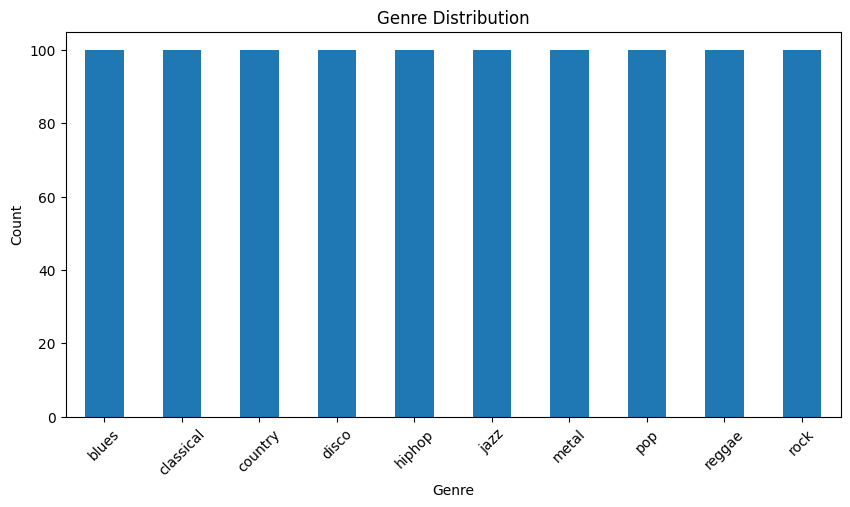

In [4]:
# class distribution
plt.figure(figsize=(10,5))
train_df['genre'].value_counts().plot(kind='bar')
plt.title("Genre Distribution")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

Observations
- Perfectly balanced
- 100 in each genre

## Raw Waveform

In [5]:
def get_audio_info(path):
    y, sr = librosa.load(path, sr=None)
    duration = librosa.get_duration(y=y, sr=sr)
    return sr, duration

sample_rows = train_df.sample(5, random_state=SEED)

for idx, row in sample_rows.iterrows():
    sr, dur = get_audio_info(row["drums"])
    print(f"{row['genre']} | SR: {sr} | Duration: {dur:.2f}s")

jazz | SR: 44100 | Duration: 30.01s
pop | SR: 44100 | Duration: 30.00s
pop | SR: 44100 | Duration: 30.00s
metal | SR: 44100 | Duration: 30.00s
hiphop | SR: 44100 | Duration: 30.01s


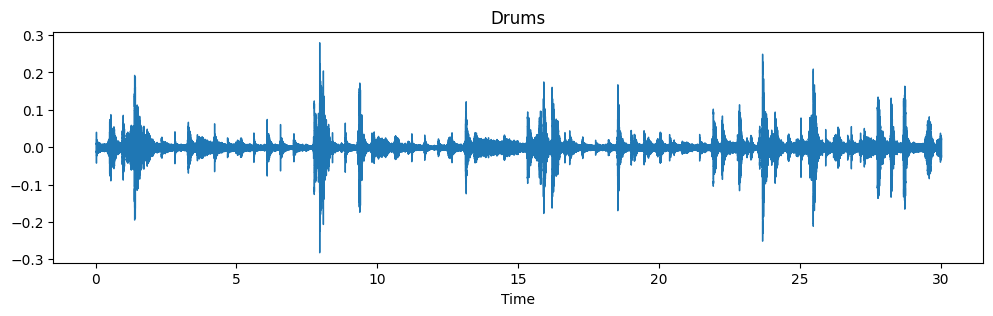

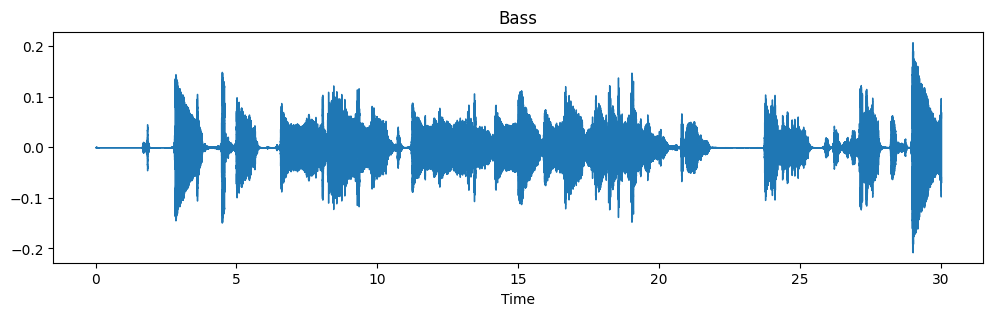

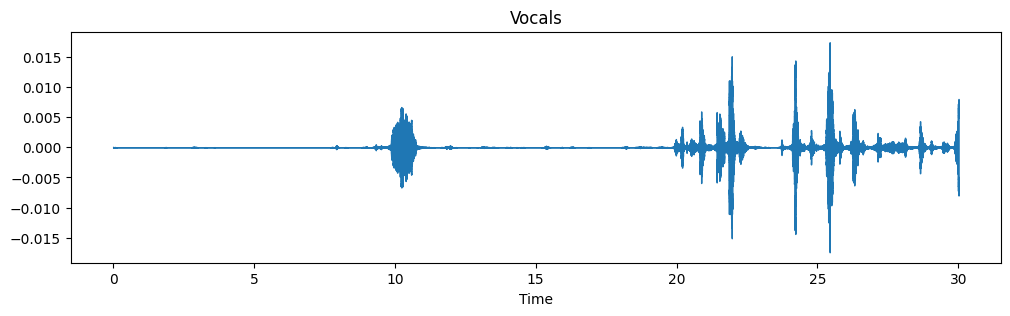

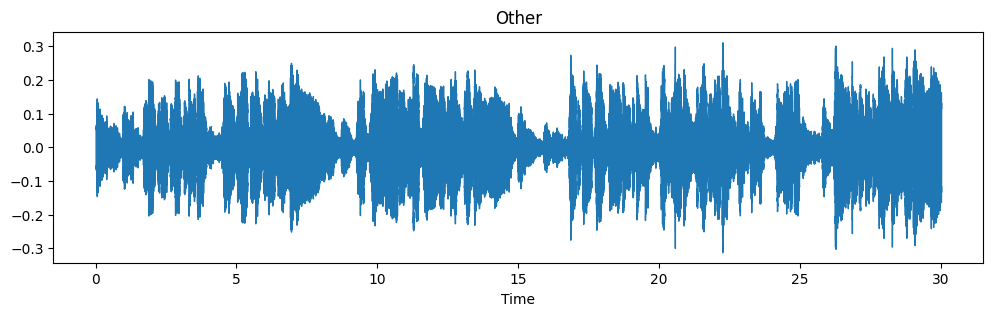

In [6]:
def plot_waveform(path, title="Waveform"):
    y, sr = librosa.load(path, sr=22050)
    
    plt.figure(figsize=(12,3))
    librosa.display.waveshow(y, sr=sr)
    plt.title(title)
    plt.show()

sample = train_df.sample(1).iloc[0]

plot_waveform(sample["drums"], "Drums")
plot_waveform(sample["bass"], "Bass")
plot_waveform(sample["vocals"], "Vocals")
plot_waveform(sample["other"], "Other")

Observations
- Drums
  - highly spiky
  - tempo + rhythm is the key genre signal
- Bass
  - Smooth, low freq dominant

- Vocals
  - Vocals are sometimes missing
  - not alone reliable

- Other
  - Mixed harmonic content
  - Carries background instruments

Bass --> low freq
Vocals --> mid freq
Drums --> Wide + transient
Other --> Full spectrum

## Mel-Spectrogram

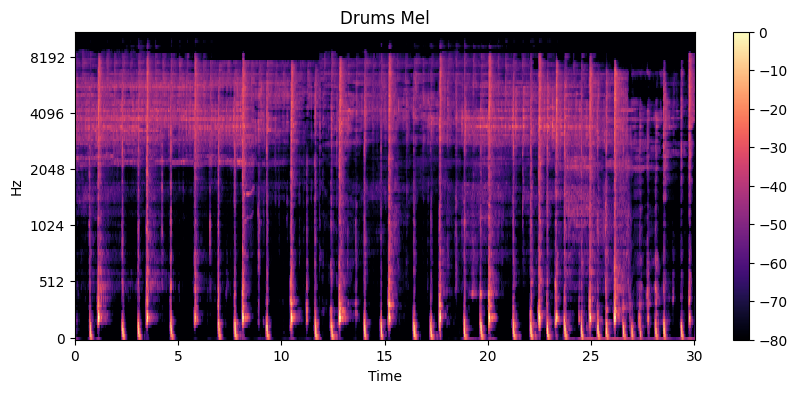

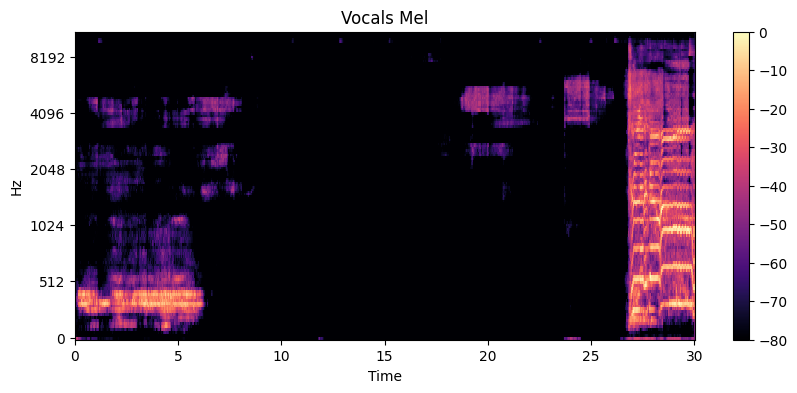

In [7]:
def plot_mel(path, title="Mel Spectrogram"):
    y, sr = librosa.load(path, sr=22050)
    
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    
    plt.figure(figsize=(10,4))
    librosa.display.specshow(mel_db, sr=sr, x_axis='time', y_axis='mel')
    plt.colorbar()
    plt.title(title)
    plt.show()

sample = train_df.sample(1).iloc[0]

plot_mel(sample["drums"], "Drums Mel")
plot_mel(sample["vocals"], "Vocals Mel")

Observation
- Drum mel --> vertical lines, wide frequency spread
- Vocals mel --> horizontal harmonic bands, sparse time regions

## Mashup Simulation

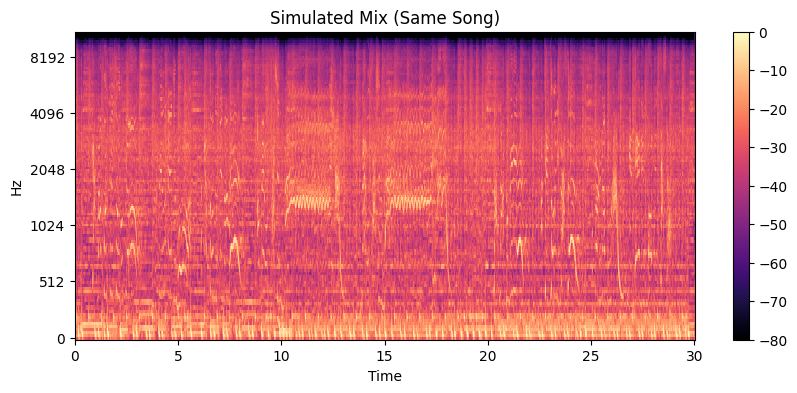

In [8]:
def load_audio(path, sr=22050):
    y, _ = librosa.load(path, sr=sr)
    return y

def mix_stems(row, sr=22050):
    y_drums = load_audio(row['drums'], sr)
    y_bass = load_audio(row['bass'], sr)
    y_vocals = load_audio(row['vocals'], sr)
    y_other = load_audio(row['other'], sr)

    # make same length
    min_len = min(len(y_drums), len(y_bass), len(y_vocals), len(y_other))

    y = (
        y_drums[:min_len] +
        y_bass[:min_len] +
        y_vocals[:min_len] +
        y_other[:min_len]
    )

    return y

sample = train_df.sample(1).iloc[0]
y_mix = mix_stems(sample)

mel = librosa.feature.melspectrogram(y=y_mix, sr=22050, n_mels=128)
mel_db = librosa.power_to_db(mel, ref=np.max)

plt.figure(figsize=(10,4))
librosa.display.specshow(mel_db, sr=22050, x_axis='time', y_axis='mel')
plt.title("Simulated Mix (Same Song)")
plt.colorbar()
plt.show()

## Cross Song mashup simulation

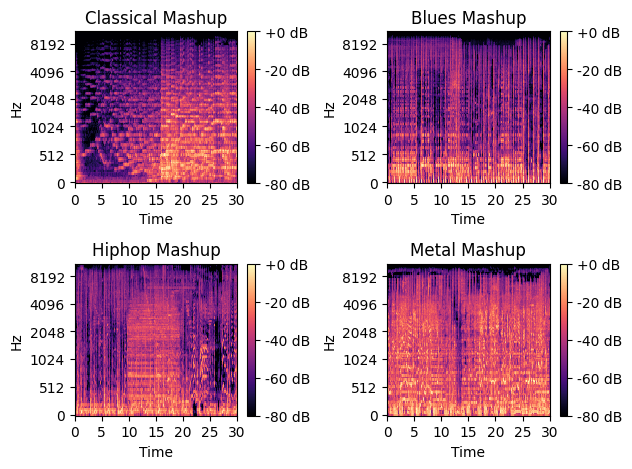

In [9]:
def cross_song_mix(df, genre, sr=22050):
    subset = df[df['genre'] == genre].sample(4)
    
    y_drums = load_audio(subset.iloc[0]["drums"], sr)
    y_bass = load_audio(subset.iloc[1]["bass"], sr)
    y_vocals = load_audio(subset.iloc[2]["vocals"], sr)
    y_other = load_audio(subset.iloc[3]["other"], sr)
    
    min_len = min(len(y_drums), len(y_bass), len(y_vocals), len(y_other))
    
    y = (
        y_drums[:min_len] +
        y_bass[:min_len] +
        y_vocals[:min_len] +
        y_other[:min_len]
    )
    
    return y

plot_genres = ['classical', 'blues', 'hiphop', 'metal']

for i, genre in enumerate(plot_genres, 1):
    y_cross = cross_song_mix(train_df, genre)
    
    mel = librosa.feature.melspectrogram(y=y_cross, sr=22050, n_mels=128)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    
    plt.subplot(2, 2, i)
    librosa.display.specshow(mel_db, sr=22050, x_axis='time', y_axis='mel')
    plt.title(f"{genre.capitalize()} Mashup")
    plt.colorbar(format='%+2.0f dB')

plt.tight_layout()
plt.show()

Observations
- Clean and smooth transitions
- Real mashups wont be this smooth and dense

## Noise Analysis

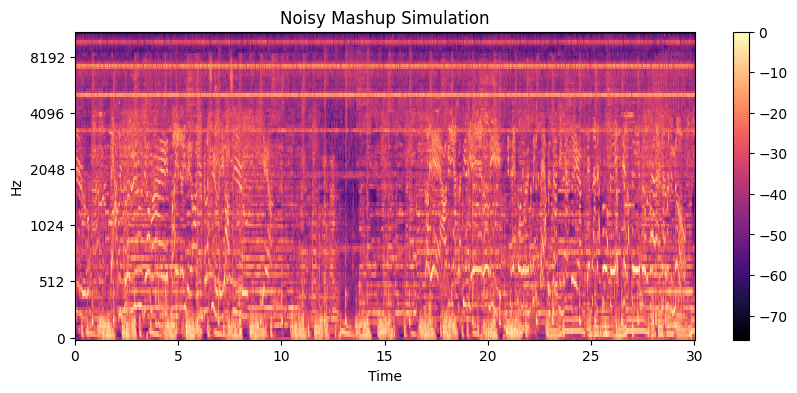

In [10]:
noise_files = os.listdir(NOISE_DIR)
noise_path = os.path.join(NOISE_DIR, random.choice(noise_files))

y_noise, sr = librosa.load(noise_path, sr=22050)

if len(y_noise) < len(y_cross):
    repeat_factor = int(np.ceil(len(y_cross) / len(y_noise)))
    y_noise = np.tile(y_noise, repeat_factor)

# match length
y_noise = y_noise[:len(y_cross)]

y_noisy = y_cross + 0.3 * y_noise

mel = librosa.feature.melspectrogram(y=y_noisy, sr=22050, n_mels=128)
mel_db = librosa.power_to_db(mel, ref=np.max)

plt.figure(figsize=(10,4))
librosa.display.specshow(mel_db, sr=22050, x_axis='time', y_axis='mel')
plt.title("Noisy Mashup Simulation")
plt.colorbar()
plt.show()

Observation
- Noise fills high freq regions
- Blurs structure
- Appears in patches

## Test mashup visualization

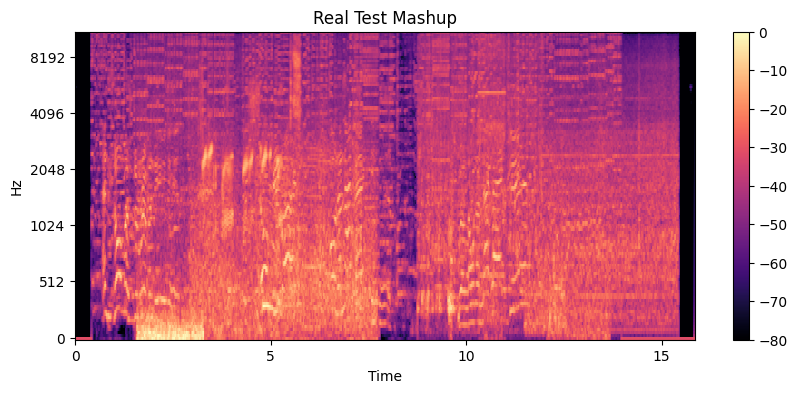

In [11]:
test_files = os.listdir(MASHUP_DIR)
test_path = os.path.join(MASHUP_DIR, random.choice(test_files))

plot_mel(test_path, "Real Test Mashup")

Observation
- noise is not uniform
- appears in patches
- sometimes dominates, sometimes subtle

# Somewhat trying to mimic Test Mashup
- trimming / cropping
- adding gain
- speeding / slowing in between
- adding noise from ESC-50
- Scaling to [-3, 3]

In [12]:
SR = 22050
DURATION = 9
SAMPLES = SR * DURATION

N_MELS = 128
NUM_CLASSES = 10

BATCH_SIZE = 8

NOISE_PROB = 0.8
TIME_STRETCH_PROB = 0.0
GAIN_PROB = 0.7

In [13]:
# helper functions

def load_audio(path, sr=SR):
    y, _ = librosa.load(path, sr=sr)
    return y

def fix_length(y, target_len=SAMPLES):
    if len(y) > target_len:
        start = np.random.randint(0, len(y) - target_len)
        y = y[start : start + target_len]
    else:
        pad = target_len - len(y)
        y = np.pad(y, (0, pad))

    return y

def random_gain(y):
    gain = np.random.uniform(0.5, 1.5)
    return y * gain

def random_time_stretch(y):
    rate = np.random.uniform(0.8, 1.2)
    return librosa.effects.time_stretch(y, rate=rate)

def add_noise(y, noise_files):
    noise_path = random.choice(noise_files)
    noise, _ = librosa.load(noise_path, sr=sr)

    noise = fix_length(noise)

    scale = np.random.uniform(0.05, 0.3)
    return y + scale * noise

def to_mel(y):
    mel = librosa.feature.melspectrogram(
        y=y,
        sr=SR,
        n_mels=N_MELS,
        fmax=SR // 2
    )
    mel = librosa.power_to_db(mel, ref=np.max)
    return mel

# cross stem mixing
def create_mashup(df, genre, noise_files):
    subset = df[df['genre'] == genre].sample(4)

    stems = []

    for i, stem_name in enumerate(["drums", "bass", "vocals", "other"]):
        path = subset.iloc[i][stem_name]
        y = load_audio(path)

        # augmentations
        if np.random.rand() < TIME_STRETCH_PROB:
            y = random_time_stretch(y)

        y = fix_length(y)

        if np.random.rand() < GAIN_PROB:
            y = random_gain(y)

        stems.append(y)

    # mix
    y = sum(stems)

    # noise
    if np.random.rand() < NOISE_PROB:
        y = add_noise(y, noise_files)

    # normalise
    y = y / (np.max(np.abs(y)) + 1e-6)

    return y

In [14]:
# dataset class
class MashupDataset(Dataset):
    def __init__(self, df, noise_dir):
        self.df = df
        self.genres = sorted(df['genre'].unique())
        self.genre_to_idx = {g: i for i, g in enumerate(self.genres)}

        self.noise_files = [
            os.path.join(noise_dir, f)
            for f in os.listdir(noise_dir)
        ]

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        genre = row['genre']

        y = create_mashup(self.df, genre, self.noise_files)

        mel = to_mel(y)

        # normalise mel
        mel = (mel - mel.mean()) / (mel.std() + 1e-6)

        mel = torch.tensor(mel).float().unsqueeze(0) # (1, n_mels, time)

        label = torch.tensor(self.genre_to_idx[genre]).long()

        return mel, label


# sanity check
dataset = MashupDataset(train_df, NOISE_DIR)

mel, label = dataset[0]

print("Mel Shape: ", mel.shape)
print("Label: ", label)

Mel Shape:  torch.Size([1, 128, 388])
Label:  tensor(0)


In [15]:
class ValDataset(Dataset):
    def __init__(self, df):
        self.df = df
        self.genres = sorted(df['genre'].unique())
        self.genre_to_idx = {g: i for i, g in enumerate(self.genres)}
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        
        # use SAME song stems (not cross mixing)
        y_drums = load_audio(row["drums"])
        y_bass = load_audio(row["bass"])
        y_vocals = load_audio(row["vocals"])
        y_other = load_audio(row["other"])
        
        min_len = min(len(y_drums), len(y_bass), len(y_vocals), len(y_other))
        
        y = (
            y_drums[:min_len] +
            y_bass[:min_len] +
            y_vocals[:min_len] +
            y_other[:min_len]
        )
        
        y = fix_length(y)
        
        mel = to_mel(y)
        mel = (mel - mel.mean()) / (mel.std() + 1e-6)
        
        mel = torch.tensor(mel).float().unsqueeze(0)
        label = torch.tensor(self.genre_to_idx[row['genre']]).long()
        
        return mel, label

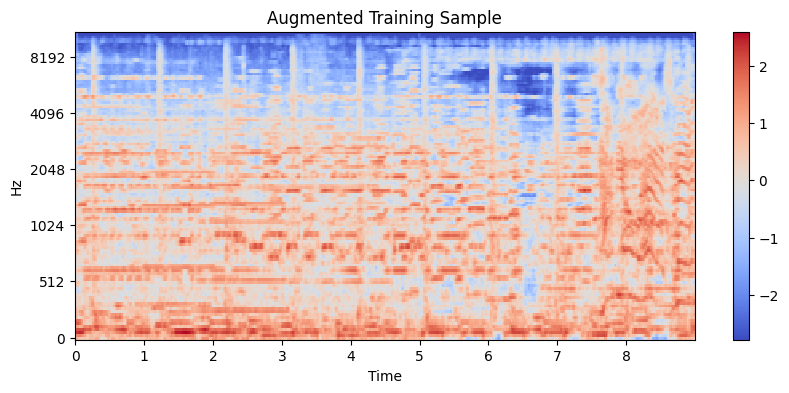

In [16]:
plt.figure(figsize=(10,4))
librosa.display.specshow(mel.squeeze(0).numpy(), sr=SR, x_axis='time', y_axis='mel')
plt.title("Augmented Training Sample")
plt.colorbar()
plt.show()

Observation
- noise in the top (high freq region)
- Strong high freq energy
- Messy -- somewhat tries to mimic test
- Discontinuous

# Scratch CNN

Architecture that I am thinking of is

Conv Block
- Conv2d layer --> kernel size = 3 and padding = 1
- batch norm layer
- relu
- maxpool2d of size 2x2

And we will have our CNN as
- 4 conv block
- pooling layer - AdaptiveAvgPool
- FC layer - 1 FC layer with relu and dropout followed by classifier



In [17]:
# class ConvBlock(nn.Module):
#     def __init__(self, in_c, out_c):
#         super().__init__()
#         self.block = nn.Sequential(
#             nn.Conv2d(in_c, out_c, kernel_size=3, padding=1),
#             nn.BatchNorm2d(out_c),
#             nn.ReLU(),
#             nn.MaxPool2d(2)
#         )

#     def forward(self, x):
#         return self.block(x)


# class ScratchCNN(nn.Module):
#     def __init__(self, num_classes=10):
#         super().__init__()

#         self.features = nn.Sequential(
#             ConvBlock(1, 32),
#             ConvBlock(32, 64),
#             ConvBlock(64, 128),
#             ConvBlock(128, 256),
#         )

#         self.pool = nn.AdaptiveAvgPool2d((1, 1))

#         self.classifier = nn.Sequential(
#             nn.Flatten(),
#             nn.Linear(256, 128),
#             nn.ReLU(),
#             nn.Dropout(0.3),
#             nn.Linear(128, num_classes)
#         )

#     def forward(self, x):
#         x = self.features(x)
#         x = self.pool(x)
#         x = self.classifier(x)
#         return x

In [18]:
# class GenreClassifier(L.LightningModule):
#     def __init__(self, model, lr=1e-3):
#         super().__init__()
#         self.model = model
#         self.lr = lr
#         self.criterion = nn.CrossEntropyLoss()

#         self.val_preds = []
#         self.val_targets = []

#     def forward(self, x):
#         return self.model(x)

#     def training_step(self, batch, batch_idx):
#         x, y = batch
#         logits = self(x)
#         loss = self.criterion(logits, y)

#         self.log("train_loss", loss, prog_bar=True, on_step=False, on_epoch=True,)

#     def validation_step(self, batch, batch_idx):
#         x, y = batch
#         logits = self(x)
#         loss = self.criterion(logits, y)

#         preds = torch.argmax(logits, dim=1)

#         self.val_preds.extend(preds.cpu().numpy())
#         self.val_targets.extend(y.cpu().numpy())

#         self.log("val_loss", loss, prog_bar=True, on_step=False, on_epoch=True,)

#     def on_validation_epoch_end(self):
#         f1 = f1_score(self.val_targets, self.val_preds, average="macro")
#         self.log("val_f1", f1, prog_bar=True, on_step=False, on_epoch=True,)

#         self.val_preds.clear()
#         self.val_targets.clear()

#     def configure_optimizers(self):
#         return torch.optim.Adam(self.parameters(), lr=self.lr)

In [19]:
# train_df_split, val_df = train_test_split(
#     train_df,
#     test_size=0.1,
#     stratify=train_df['genre'],
#     random_state=42
# )

# train_dataset = MashupDataset(train_df_split, NOISE_DIR)
# val_dataset = ValDataset(val_df)

# train_loader = DataLoader(train_dataset, 
#                           batch_size=BATCH_SIZE, 
#                           shuffle=True, 
#                           num_workers=4,
#                           pin_memory=True
#                          )
# val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)


# Dry Run Loop

In [20]:
# model = ScratchCNN(num_classes=NUM_CLASSES)
# lit_model = GenreClassifier(model)

# trainer = L.Trainer(
#     max_epochs=1,
#     accelerator="cuda" if torch.cuda.is_available() else "cpu",
#     devices=1,
#     log_every_n_steps=1
# )

# trainer.fit(lit_model, train_loader, val_loader)

In [21]:
# from pytorch_lightning.callbacks import ModelCheckpoint

# checkpoint_callback = ModelCheckpoint(
#     monitor="val_f1",
#     mode="max",
#     save_top_k=1,
#     filename="best-model"
# )


# trainer = L.Trainer(
#     max_epochs=19,
#     accelerator="cuda" if torch.cuda.is_available() else "cpu",
#     devices=1,

#     precision=16,

#     log_every_n_steps=10,

#     enable_checkpointing=True,

#     gradient_clip_val=1.0,  # stability
#     callbacks=[checkpoint_callback],

#     accumulate_grad_batches=1,
# )

# train_loader = DataLoader(
#     train_dataset,
#     batch_size=16,
#     shuffle=True,
#     num_workers=4,
#     pin_memory=True
# )

# val_loader = DataLoader(
#     val_dataset,
#     batch_size=16,
#     shuffle=False,
#     num_workers=4,
#     pin_memory=True
# ) 

In [22]:
# model = ScratchCNN(num_classes=NUM_CLASSES)
# lit_model = GenreClassifier(model, lr=1e-3)

# trainer.fit(lit_model, train_loader, val_loader)

Observation
- Was not crossing even 0.1 in val/f1
- REASONS:
- - Preprocessing to mimic test is not matching
  - No time stretch
  - Not all time stem mixing
  - not all time adding noise
  - So wheneevr Actual Test / Val dataset it sees, it is not working good.


# New Preprocess

### What things i am planning to do
- Always 100% times cross-song mixing
- Per-stem tempo augment before mixing --> speeding / slowing down individual bass / drum / ... before final mixup --> building chaotic garbage
- Injecting heavier / aggressive noise from the ESC-50 directory --> SNR (Signal to Noise) --> Ratio of actual loudnedss to noise loudness --> low SNR = more noise loudness (0 to 15db SNR)
- Sometimes 2 noise in one mashup
- Mel + Delta + Delta-Delta
- 5 crop TTA (Test Time Augmentation) --> reduces variance by generalising well
- MixUp Augmentation
- OneCycleLR with warmup

In [23]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
L.seed_everything(SEED, workers=True)

BASE_DIR = Path('/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup')
STEMS_DIR = BASE_DIR / 'genres_stems'
ESC_DIR = BASE_DIR / "ESC-50-master" / "audio"
MASHUP_DIR = BASE_DIR / "mashups"
TEST_CSV = BASE_DIR / "test.csv"
OUTPUT_DIR = Path("/kaggle/working/")

Seed set to 42


In [52]:
CFG = dict(
    sr = 22050,
    duration = 10,
    n_mels = 128,
    n_fft = 2048,
    hop_length = 512,
    fmax = 8000,
    img_size = 224,

    batch_size = 32,
    num_workers =4,
    val_split = 0.15,
    max_epochs = 40,
    lr = 3e-4,
    weight_decay = 1e-4,
    label_smoothing = 0.1,

    num_classes = 10,
    genres = ['blues', 'classical', 'country', 'disco', 'hiphop',
                    'jazz', 'metal', 'pop', 'reggae', 'rock'],

    aug_prob = 0.6,
    mixup_alpha = 0.4,

    snr_min = 0,
    snr_max = 15,
    multi_noise_prob = 0.3,

    tta_n_crops = 5,

    kaggle_user = "kaushalvaid",
    kh_dataset = "messy-mashup-checkpoints-v2",
    wadb_project = "24f2000681-t12026",
)

GENRE_TO_IDX = {g: i for i, g in enumerate(CFG['genres'])}
IDX_TO_GENRE = {i: g for g, i in GENRE_TO_IDX.items()}
SAMPLES   = CFG['sr'] * CFG['duration']

print('Config loaded.')
print(f'Genres : {CFG["genres"]}')
print(f'Clip   : {SAMPLES:,} samples = {CFG["duration"]}s @ {CFG["sr"]} Hz')

Config loaded.
Genres : ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']
Clip   : 220,500 samples = 10s @ 22050 Hz


# Preprocessing

In [25]:
def load_audio(path, sr, duration, offset_frac=None):
    y, sr_ = librosa.load(path, sr=sr, mono=True)
    n = len(y)
    target = sr * duration

    # pad if target > actual
    if n < target:
        repeats = (target // n) + 1
        y = np.tile(y, repeats)[: target]

    else:
        # trim
        if offset_frac is not None:
            # determining position for TTA
            start = int(offset_frac * (n - target))
        else:
            start = random.randint(0, n - target)

        y = y[start: start + target]

    return y.astype(np.float32)

In [26]:
def audio_to_melspec(y, cfg):
    mel = librosa.feature.melspectrogram(
        y = y,
        sr = cfg['sr'],
        n_mels = cfg["n_mels"],
        n_fft = cfg["n_fft"],
        hop_length = cfg["hop_length"],
        fmax = cfg['fmax']
    )
    meldb = librosa.power_to_db(mel, ref=np.max).astype(np.float32)
    delta1 = librosa.feature.delta(meldb, width=9).astype(np.float32)
    delta2 = librosa.feature.delta(meldb, width=9, order=2).astype(np.float32)
    return np.stack([meldb, delta1, delta2], axis=0)

In [27]:
# applying minmaxScaling

def normalise_channels(spec):
    out = np.empty_like(spec)
    for c in range(spec.shape[0]):
        mini, maxi = spec[c].min(), spec[c].max()
        if maxi - mini > 1e-6:
            out[c] = (spec[c] - mini) / (maxi - mini)
        else:
            out[c] = np.zeros_like(spec[c])

    return out

In [28]:
def spec_to_tensor(spec, img_size):

    # scale --> convert to tensor
    spec = normalise_channels(spec)
    t = torch.tensor(spec, dtype=torch.float32)
    t = F.interpolate(
        t.unsqueeze(0),
        size = (img_size, img_size),
        mode = "bilinear",
        align_corners = False
    ).squeeze(0)
    
    return t

#### ADding noise

In [29]:
ESC50_FILES = sorted(ESC_DIR.glob("*.wav"))
print("Totla ESC files got is ", len(ESC50_FILES))

def add_noise(y, sr, snr_min, snr_max, multi_noise_prob = 0.3):
    def _mix_one(signal, noise_path):
        noise, _ = librosa.load(noise_path, sr=sr, mono=None)

        # pad
        if len(noise) < len(signal):
            noise = np.tile(noise, (len(signal) // len(noise)) + 1)[:len(signal)]
            
        # trim
        else:
            start = random.randint(0, len(noise) - len(signal))
            noise = noise[start: start + len(signal)]

        # scaling noise
        signal_rms = np.sqrt(np.mean(signal ** 2)) + 1e-9
        noise_rms = np.sqrt(np.mean(noise ** 2)) + 1e-9

        snr_db = random.uniform(snr_min, snr_max)
        target_rms = signal_rms / (10 ** (snr_db / 20.0))

        return signal + noise * (target_rms / noise_rms)

    # first mix
    y = _mix_one(y, random.choice(ESC50_FILES))

    # secondf mix
    if random.random() < multi_noise_prob:
        y = _mix_one(y, random.choice(ESC50_FILES))

    return np.clip(y, -1.0, 1.0)

Totla ESC files got is  2000


#### Time stretch

In [30]:
def time_stretch(y, cfg):
    rate = random.uniform(0.85, 1.15)
    target = cfg["sr"] * cfg["duration"]

    y_stretched = librosa.effects.time_stretch(y, rate=rate)
    if len(y_stretched) < target:
        # pad
        y_stretched = np.tile(y_stretched, (target // len(y_stretched)) + 1)[: target]
    else:
        # trim
        y_stretched = y_stretched[: target]

    return y_stretched

#### Pitch shift and random gain

In [31]:
def pitch_shift(y, cfg):
    n_steps = random.uniform(-2, 2)
    return librosa.effects.pitch_shift(y, sr=cfg["sr"],n_steps=n_steps)

def random_gain(y):
    gain = random.uniform(0.5, 2.0)
    return np.clip(y * gain, -1.0, 1.0)

#### Spec Augment

In [32]:
class SpecAugment:
    def __init__(self, freq_mask=20, time_mask=40, num_masks=2):
        self.freq_mask = freq_mask
        self.time_mask = time_mask
        self.num_masks = num_masks

    def __call__(self, spec):
        Channel, Freq, Time = spec.shape
        for i in range(self.num_masks):
            f = random.randint(0, self.freq_mask)
            f0 = random.randint(0, max(0, Freq - f))
            spec[: f0: f0 + f, :] = 0.0

            t = random.randint(0, self.time_mask)
            t0 = random.randint(0, max(0, Time - t))
            spec[:, :, t0: t0 + t] = 0.0

        return spec

SPEC_AUGMENT = SpecAugment()

#### Stem Mix

In [33]:
STEM_NAMES = ['bass.wav', 'drums.wav', 'other.wav', 'vocals.wav']

def get_song_dirs(genre):
    return sorted((STEMS_DIR / genre).iterdir())

def build_cross_song_mashup(genre, cfg, apply_per_stem_stretch=True):
    song_dirs = get_song_dirs(genre)

    sr, dur = cfg["sr"], cfg["duration"]

    chosen = (random.sample(song_dirs, 4)
             if len(song_dirs) >= 4 else random.choices(song_dirs, k=4))

    mixed = np.zeros(sr * dur, dtype=np.float32)

    for song_dir, stem_name in zip(chosen, STEM_NAMES):
        stem_path = song_dir / stem_name
        if not stem_path.exists():
            continue

        y_stem = load_audio(str(stem_path), sr, dur)

        # per stem tempo augmentation
        if apply_per_stem_stretch and random.random() < 0.5:
            rate = random.uniform(0.90, 1.10)
            y_stem = librosa.effects.time_stretch(y_stem, rate=rate)
            if len(y_stem) < sr * dur:
                y_stem = np.tile(y_stem, (sr * dur // len(y_stem)) + 1)[:sr * dur]
            else:
                y_stem = y_stem[:sr * dur]

        
        mixed = mixed * y_stem

    # Prevent clipping from summing 4 stems
    mx = np.abs(mixed).max()
    if mx > 1e-6:
        mixed /= mx
    return mixed

# Dataset

In [34]:
class MashupDataset(Dataset):
    def __init__(self, stems_dir, genres,cfg, augment=True):
        self.stems_dir = stems_dir
        self.genres = genres
        self.cfg = cfg
        self.augment = augment

        self.samples = []
        for genre in genres:
            for song_dir in sorted((stems_dir / genre).iterdir()):
                if song_dir.is_dir():
                    self.samples.append((genre, song_dir))

        print("[Mashup Dataset] ", len(self.samples), " songs | augment=", augment)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        genre, song_dir = self.samples[idx]
        label = GENRE_TO_IDX[genre]
        cfg = self.cfg

        # build mashup
        y = build_cross_song_mashup(genre, cfg, apply_per_stem_stretch=self.augment)

        # audio augment
        if self.augment:
            # noise
            y = add_noise(y, cfg['sr'], cfg['snr_min'], cfg['snr_max'], cfg['multi_noise_prob'])

            # random gain
            if random.random() < cfg['aug_prob']:
                y = random_gain(y)

            # time stretch (tempo augment) --> 24% chance
            if random.random() < cfg['aug_prob'] * 0.4:
                y = time_stretch(y, cfg)

            # pitch shift --> 18% chance
            if random.random() < cfg['aug_prob'] * 0.3:
                y = pitch_shift(y, cgf)


        # convert mel + deltas to tensor
        spec = audio_to_melspec(y, cfg)
        tensor = spec_to_tensor(spec, cfg['img_size'])

        # spec augment
        if self.augment and random.random < cfg['aug_prob']:
            tensor = SPEC_AUGMENT(tensor)

        return tensor, torch.tensor(label, dtype=torch.long)


class InferenceDataset(Dataset):
    def __init__(self, test_csv, mashup_dir, cfg):
        self.df = pd.read_csv(test_csv)
        self.mashup_dir = mashup_dir
        self.cfg = cfg
        self.n_crops = cfg['tta_n_crops']
        self.offsets = [0.0, 0.25, 0.5, 0.75, 1.0]

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        file_id = str(row['id']).zfill(4)

        if 'filename' in row.index:
            fname = str(row['filename'])
        else:
            fname = f'song{file_id}.wav'

        path = self.mashup_dir / fname

        if not path.exists():
            path = self.mashup_dir / f'song{file_id}.wav'

        crops = []

        for offset in self.offsets:
            y = load_audio(str(path), self.cfg['sr'], self.cfg['duration'], offset_frac=offset)
            spec = audio_to_melspec(y, self.cfg)
            tensor = spec_to_tensor(spec, self.cfg['img_size'])
            crops.append(tensor)

        # (n_crops, 3, 224, 224), id
        return torch.stack(crops), str(row['id'])

### Train Val Split

In [35]:
full_ds = MashupDataset(STEMS_DIR, CFG['genres'], CFG, augment=True)
n_val = int(len(full_ds) * CFG['val_split'])
n_train = len(full_ds) - n_val

train_ds, val_ds = random_split(full_ds, [n_train, n_val], generator=torch.Generator().manual_seed(SEED))

[Mashup Dataset]  1000  songs | augment= True


In [36]:
# no augment in val bcz f1 would fluctuate due to randomness 
# (so only clean cross stemming -- no noise)
val_clean_ds = MashupDataset(STEMS_DIR, CFG['genres'], CFG, augment=False)
val_clean_indices = val_ds.indices

val_ds_final = Subset(val_clean_ds, val_clean_indices)

[Mashup Dataset]  1000  songs | augment= False


# Data Loaders

In [37]:
train_loader = DataLoader(
    train_ds,
    batch_size = CFG['batch_size'],
    shuffle = True,
    num_workers = CFG['num_workers'],
    pin_memory = True
)

val_loader = DataLoader(
    val_ds_final,
    batch_size = CFG['batch_size'],
    shuffle = False,
    num_workers = CFG['num_workers'],
    pin_memory = True
)

print("Train Samples: ", len(train_ds))
print("Val Samples: ", len(val_ds_final))
print("Train batches: ", len(train_loader), " per epich")

Train Samples:  850
Val Samples:  150
Train batches:  27  per epich


# Model Building

## ScratchCNN

Architecture --> Residual Blocks + Strided conv downsampling + spatial attention + GAP + classifier

Residual Block inspiration i got from resnet architecture --> adding input to output --> solves VGD problem

Strided Conv instead of MaxPool --> maxpool directly discards values, so strided conv learns how to downsample, it can preserve important freq rather than just taking the max

Spatial ATtention --> not qll freq are important, like metal --> high freq imp, for hiphop --> low mel bins important
Therefore this lets the model focus on the  most discriminative spectral regions

GlobalAvgPool --> less feature map, fewer parameter, less overfitting

In [38]:
class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, 3, padding=1, bias =False)
        self.bn1 = nn.BatchNorm2d(channels)
        self.conv2 = nn.Conv2d(channels, channels, 3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(channels)

    def forward(self, x):
        residual = x
        out = F.relu(self.bn1(self.conv1(x)), inplace=True)
        out = self.bn2(self.conv2(out))
        return F.relu(out + residual, inplace=True) # skip connection


class DownBlock(nn.Module):
    def __init__(self, in_channel, out_channel):
        super().__init__()
        self.conv = nn.Conv2d(in_channel, out_channel, kernel_size=3, stride=2, 
                              padding=1, bias=False)
        self.bn = nn.BatchNorm2d(out_channel)

    def forward(self, x):
        return F.relu(self.bn(self.conv(x)), inplace=True)


class SpatialAttention(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size=7, padding=3, bias=False)

    def forward(self, x):
        avg_out = x.mean(dim = 1, keepdim=True)
        max_out = x.max(dim = 1, keepdim=True)[0]
        mask = torch.sigmoid(self.conv(torch.cat([avg_out, max_out], dim = 1)))
        return x * mask


class CustomCNN(nn.Module):
    def __init__(self, num_classes = 10, dropout=0.4):
        super().__init__()
        self.stem = DownBlock(3, 32)
        self.block1 = nn.Sequential(ResidualBlock(32), DownBlock(32, 64))
        self.block2 = nn.Sequential(ResidualBlock(64), DownBlock(64, 128))
        self.block3 = nn.Sequential(ResidualBlock(128), DownBlock(128, 256))
        self.block4 = nn.Sequential(ResidualBlock(256), DownBlock(256, 512))
        self.attn = SpatialAttention()
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout * 0.5),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.attn(x)
        x = self.gap(x)
        return self.head(x)


modelCNN = CustomCNN(CFG['num_classes'])
print("CustomCNN trainable parameters: ", sum(p.numel() for p in modelCNN.parameters()))
del modelCNN
        

CustomCNN trainable parameters:  3272204


## ResNet18 -- Finetuning

Why came back from ResNet50 --> 
- 11M param vs 25M params --> could easily overfit --> reducing model complexity
- Faster training than ResNet50

2 Phase training
- if not, then large random gradients
- therefore first freezing and letting the head stabilise
- then unfreezze after a few epochs and adapt using low learning rate tio the spectrograms

In [39]:
class ResNet18Classifier(nn.Module):
    def __init__(self, num_classes=10, dropout=0.4, freeze_backbone=True):
        super().__init__()
        backbone = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        in_features = backbone.fc.in_features

        # remove original head
        backbone.fc = nn.Identity()
        self.backbone = backbone

        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(in_features, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout * 0.5),
            nn.Linear(256, num_classes),
        )

        if freeze_backbone:
            self.freeze_backbone()

    def freeze_backbone(self):
        for param in self.backbone.parameters():
            param.requires_grad = False

        print('ResNet18: backbone FROZEN (Phase 1 — head only)')

    def unfreeze_backbone(self):
        for param in self.backbone.parameters():
            param.requires_grad = True

        print('ResNet18: backbone UNFROZEN (Phase 2 — full fine-tune)')

    def forward(self, x):
        features = self.backbone(x)
        return self.head(features)

modelResNet = ResNet18Classifier(CFG['num_classes'])
total_p    = sum(p.numel() for p in modelResNet.parameters())
trainable_p = sum(p.numel() for p in modelResNet.parameters() if p.requires_grad)
print(f'ResNet18 total params      : {total_p:,}')
print(f'ResNet18 trainable (frozen): {trainable_p:,} - head only')
del modelResNet

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 155MB/s] 

ResNet18: backbone FROZEN (Phase 1 — head only)
ResNet18 total params      : 11,310,410
ResNet18 trainable (frozen): 133,898 - head only


## EfficientNet-B3 -- finetuning

EfficientNet scales width, depth, and resolution together using a fixed compound coefficient. B3 is the 3rd scaling step.
B3 achieves better accuracy than ResNet50 with half the parameters.
EfficientNet-B3 has the highest validation F1-macro of the three models (with relative to number of epochs).

In [40]:
class EfficientNetB3Classifier(nn.Module):
    def __init__(self, num_classes=10, dropout=0.4, freeze_backbone=True):
        super().__init__()
        backbone    = models.efficientnet_b3(weights=models.EfficientNet_B3_Weights.IMAGENET1K_V1)
        in_features = backbone.classifier[-1].in_features

        # remove original head
        backbone.classifier = nn.Identity()
        self.backbone = backbone

        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(in_features, 512),
            nn.SiLU(),
            nn.Dropout(dropout * 0.5),
            nn.Linear(512, num_classes),
        )

        if freeze_backbone:
            self.freeze_backbone()

    def freeze_backbone(self):
        for p in self.backbone.parameters():
            p.requires_grad = False
        print('EfficientNet-B3: backbone FROZEN (Phase 1 — head only)')

    def unfreeze_backbone(self):
        for p in self.backbone.parameters():
            p.requires_grad = True
        print('EfficientNet-B3: backbone UNFROZEN (Phase 2 — full fine-tune)')

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        features = self.backbone(x)   # (B, 1536)
        return self.head(features)    # (B, 10)


modelEff = EfficientNetB3Classifier(CFG['num_classes'])
total_p    = sum(p.numel() for p in modelEff.parameters())
trainable_p = sum(p.numel() for p in modelEff.parameters() if p.requires_grad)
print(f'EfficientNet-B3 total params      : {total_p:,}')
print(f'EfficientNet-B3 trainable (frozen): {trainable_p:,} - head only')
del modelEff


Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 167MB/s] 


EfficientNet-B3: backbone FROZEN (Phase 1 — head only)
EfficientNet-B3 total params      : 11,488,306
EfficientNet-B3 trainable (frozen): 792,074 - head only


# PyTorch Lightning Module

In [41]:
def mixup_data(x, y, alpha=0.4):
    """
    Idea --> MixUp augmentation (Zhang et al., 2018).
    
    Linearly interpolates two training examples and their labels:
        x_mix = lambda·xi + (1-lambda)·xj
        loss  = lambda·CE(logits, yi) + (1-lambda)·CE(logits, yi)
    """
        
    if alpha <= 0:
        return x, y, y, 1.0

    lam = float(np.random.beta(alpha, alpha))
    bs = x.size(0)
    idx = torch.randperm(bs, device=x.device)
    return lam * x + (1 - lam) * x[idx], y, y[idx], lam


class GenreClassifier(L.LightningModule):
    def __init__(self, model, cfg, model_name='model', phase2=False):
        super().__init__()
        self.model      = model
        self.cfg        = cfg
        self.model_name = model_name
        self.phase2     = phase2

        self.criterion = nn.CrossEntropyLoss(label_smoothing=cfg['label_smoothing'])

        self.val_preds = []
        self.val_labels = []
        self.save_hyperparameters(ignore=['model'])


    def forward(self, x):
        return self.model(x)

    
    def training_step(self, batach, batch_idx):
        x, y = batch

        # apply mixup
        x_min, y_a, y_b, lam = mixup_data(x, y, self.cfg['mixup_alpha'])

        logits = self(x_mix)

        # mixed loss: weighted average of two cross-entropy terms
        loss = (lam * self.criterion(logits, y_a)
                + (1 - lam) * self.criterion(logits, y_b))

        # accuracy computed against the dominant label (y_a)
        preds = logits.argmax(dim=1)
        acc = (preds == y_a).float().mean()

        self.log('train/loss', loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log('train/acc',  acc,  on_step=False, on_epoch=True, prog_bar=True)
        return loss


    def validation_step(self, batch, batch_idx):
        x, y   = batch
        logits = self(x)
        loss   = self.criterion(logits, y)
        preds  = logits.argmax(dim=1)

        # Accumulate for epoch-level F1 computation
        self.val_preds.extend(preds.cpu().numpy())
        self.val_labels.extend(y.cpu().numpy())

        self.log('val/loss', loss, on_step=False, on_epoch=True, prog_bar=True)
        return loss


    def on_validation_epoch_end(self):
        if not self.val_preds:
            return

        preds  = self.val_preds
        labels = self.val_labels

        f1  = f1_score(labels, preds, average='macro', zero_division=0)
        acc = accuracy_score(labels, preds)
        self.log('val/f1_macro', f1,  prog_bar=True)
        self.log('val/acc',      acc, prog_bar=True)

        # per class f1 in wandb
        per_class = f1_score(labels, preds, average=None, zero_division=0)
        for i, g in enumerate(CFG['genres']):
            self.log(f'val/f1_{g}', float(per_class[i]))

        # print classification report every 5 epochs for visibility
        # if self.current_epoch % 5 == 0:
        #     print(f'\n[Epoch {self.current_epoch}] val F1-macro: {f1:.4f}')
        #     print(classification_report(
        #         labels, preds,
        #         target_names=CFG['genres'], zero_division=0
        #     ))

        self.val_preds  = []
        self.val_labels = []


    def configure_optimizers(self):
        if self.phase2 and hasattr(self.model, 'backbone'):
            # differential learning rates for Phase 2
            param_groups = [
                {'params': self.model.backbone.parameters(),
                 'lr': self.cfg['lr'] * 0.1},
                {'params': self.model.head.parameters(),
                 'lr': self.cfg['lr']},
            ]
        else:
            param_groups = [
                p for p in self.model.parameters() if p.requires_grad
            ]

        optimizer = torch.optim.AdamW(
            param_groups,
            lr=self.cfg['lr'],
            weight_decay=self.cfg['weight_decay'],
        )

        total_steps = len(train_loader) * self.cfg['max_epochs']
        scheduler   = torch.optim.lr_scheduler.OneCycleLR(
            optimizer,
            max_lr          = self.cfg['lr'],
            total_steps     = total_steps,
            pct_start       = 0.1,
            anneal_strategy = 'cos',
            div_factor      = 25,
            final_div_factor= 1e4,
        )

        return {
            'optimizer': optimizer,
            'lr_scheduler': {
                'scheduler': scheduler,
                'interval' : 'step',    # OneCycleLR must step every batch
            },
        }

# Dry Run Loop

In [42]:
DRY_RUN = False


def make_dry_loaders(cfg, n_batches: int = 2):
    """Create tiny loaders with exactly n_batches batches each."""
    from torch.utils.data import Subset
    n  = cfg['batch_size'] * n_batches
    tr = Subset(train_ds, list(range(min(n, len(train_ds)))))
    vl = Subset(val_ds_final, list(range(min(n, len(val_ds_final)))))
    tl = DataLoader(tr, batch_size=cfg['batch_size'], shuffle=True,  num_workers=2)
    vl = DataLoader(vl, batch_size=cfg['batch_size'], shuffle=False, num_workers=2)
    return tl, vl


def dry_run_model(model: nn.Module, model_name: str, cfg: dict):
    print(f'\n{"="*60}')
    print(f'  DRY RUN: {model_name}')
    print(f'{"="*60}')
    tl, vl = make_dry_loaders(cfg)
    lit = GenreClassifier(model, cfg, model_name=model_name)
    trainer = L.Trainer(
        max_epochs          = 1,
        limit_train_batches = 2,
        limit_val_batches   = 2,
        enable_checkpointing= False,
        logger              = False,
        enable_progress_bar = True,
        accelerator         = 'auto',
        devices             = 1,
    )
    trainer.fit(lit, tl, vl)
    print(f' {model_name} dry run passed')


if DRY_RUN:
    dry_run_model(CustomCNN(CFG['num_classes']),                    'CustomCNN',       CFG)
    dry_run_model(ResNet18Classifier(CFG['num_classes']),           'ResNet18',        CFG)
    dry_run_model(EfficientNetB3Classifier(CFG['num_classes']),     'EfficientNet-B3', CFG)
    print('\nAll 3 dry runs passed! Set DRY_RUN = False for full training.')
else:
    print('DRY_RUN = False — proceeding to full training.')

DRY_RUN = False — proceeding to full training.


# Full Training

In [43]:
# W&B login
from kaggle_secrets import UserSecretsClient
secrets  = UserSecretsClient()
wandb_key = secrets.get_secret("WANDB_API_KEY")
wandb.login(key=wandb_key)
print('W&B login successful')

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


W&B login successful


In [45]:
def get_callbacks(momdel_name, monitor='val/f1_macro'):
    return [
        ModelCheckpoint(
            dirpath = OUTPUT_DIR / 'checkpoints',
            filename = f'{model_name}_best',
            monitor = monitor,
            mode = 'max',
            save_top_k = 1,
            verbose = True,
        ),
        EarlyStopping(
            monitor= monitor,
            mode = 'max',
            patience= 8,
            verbose = True,
        ),
        LearningRateMonitor(logging_interval='epoch'),
    ]

In [46]:
# def train_model(model, model_name, cfg, train_loader, val_loader, phase2_unfreeze=False):
#     print("--------------------- TRAINING ", model_name, "-------------------------")

#     # phase 1
#     cfg_p1 = dict(cfg)
#     cfg_p1['max_spochs'] =10 if phase2_unfreeze else cfg['max_epochs']

#     wb_logger = WandbLogger(
#         project = cfg['wandb_project'],
#         name = model_name,
#         log_model = False,
#         resume = "allow"
#     )
    
#     wb_logger.experiment.config.update(cfg)

#     lit1 = GenreClassifier(model, cfg_p1, model_name=model_name, phase2=False)
#     t1 = L.Trainer(
#         max_epochs = cfg_p1['max_epochs'],
#         accelerator = 'gpu',
#         devices = 1,
#         precision = '16-mixed',
#         callbacks = get_callbacks(model_name),
#         logger= wb_logger,
#         log_every_n_steps = 10,
#         enable_progress_bar = True,
#     )

#     t1.fit(lit1, train_loader, val_loader)

#     if not phase2_unfreeze or not hasattr(model, 'unfreeze_backbone'):
#         wandb.finish()
#         return lit1

#     # phase 2
#     print(f'\n--------- Phase 2: unfreezing backbone for {model_name} --------')
#     model.unfreeze_backbone()

#     cfg_p2 = dict(cfg)
#     cfg_p2['max_epochs'] = 30
#     cfg_p2['lr'] = 3e-4   # head LR; backbone gets 0.1× inside configure_optimizers

#     lit2 = GenreClassifier(model, cfg_p2,
#                            model_name=f'{model_name}', phase2=True)
#     t2   = L.Trainer(
#         max_epochs = cfg_p2['max_epochs'],
#         accelerator = 'gpu',
#         devices= 1,
#         precision = '16-mixed',
#         callbacks= get_callbacks(f'{model_name}_phase2'),
#         logger = wb_logger,
#         log_every_n_steps = 10,
#         enable_progress_bar = True,
#     )
#     t2.fit(lit2, train_loader, val_loader)
#     wandb.finish()
#     return lit2

In [47]:
# if not DRY_RUN:
#     # Custom CNN
#     model1 = CustomCNN(CFG['num_classes'])
#     lit1   = train_model(model1, 'CustomCNN',
#                          CFG, train_loader, val_loader,
#                          phase2_unfreeze=False)

#     # ResNet18
#     model2 = ResNet18Classifier(CFG['num_classes'], freeze_backbone=True)
#     lit2   = train_model(model2, 'ResNet18',
#                          CFG, train_loader, val_loader,
#                          phase2_unfreeze=True)

#     # EfficientNet-B3
#     model3 = EfficientNetB3Classifier(CFG['num_classes'], freeze_backbone=True)
#     lit3   = train_model(model3, 'EfficientNet-B3',
#                          CFG, train_loader, val_loader,
#                          phase2_unfreeze=True)

#     print('All 3 models trained')
# else:
#     print('DRY_RUN = True — full training skipped.')

# Kagglehub Upload

In [48]:
# if not DRY_RUN:
#     ckpt_dir   = OUTPUT_DIR / 'checkpoints'
#     ckpt_files = list(ckpt_dir.glob('*.ckpt'))
#     print(f'Checkpoints to upload: {[f.name for f in ckpt_files]}')

#     # Save config so we can reconstruct models in future sessions
#     with open(ckpt_dir / 'config.json', 'w') as f:
#         json.dump(CFG, f, indent=2)

#     handle = kagglehub.dataset_upload(
#         handle            = f"{CFG['kaggle_user']}/{CFG['kh_dataset']}",
#         local_dataset_dir = str(ckpt_dir),
#         version_notes     = 'Added CustomCNN, ResNet18, and EfficientNet-B3 checkpoints'
#     )
#     print(f'Uploaded: {handle}')
# else:
#     print('DRY_RUN = True — upload skipped.')

# Inference - 5 crop TTA

In [53]:
print('Downloading checkpoints...')
ckpt_root = Path(kagglehub.dataset_download(
    f"{CFG['kaggle_user']}/{CFG['kh_dataset']}"
))
print(f'Downloaded to: {ckpt_root}')
print('Files:', [f.name for f in ckpt_root.iterdir()])


def find_best_ckpt(name_pattern: str, base: Path) -> Path:
    """
    Find checkpoint for a given model. Prefers phase2 over phase1
    because phase2 includes backbone fine-tuning (better weights).
    """
    all_matches = list(base.glob(f'*{name_pattern}*.ckpt'))
    assert all_matches, f'No checkpoint found matching: {name_pattern}'
    phase2 = [m for m in all_matches if 'phase2' in m.name]
    chosen = phase2[0] if phase2 else all_matches[0]
    print(f'Using checkpoint: {chosen.name}')
    return chosen


DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Inference device: {DEVICE}')

Downloaded to: /kaggle/input/datasets/kaushalvaid/messy-mashup-checkpoints-v2
Files: ['config.json', 'EfficientNet-B3_best.ckpt', 'EfficientNet-B3_phase2_best.ckpt']
Inference device: cpu


In [55]:
ckpt_path   = find_best_ckpt('EfficientNet-B3', ckpt_root)
effnet_model = EfficientNetB3Classifier(CFG['num_classes'], freeze_backbone=False)

lit_final = GenreClassifier.load_from_checkpoint(
    checkpoint_path = str(ckpt_path),
    model           = effnet_model,
    cfg             = CFG,
    strict          = True,
)
lit_final.eval()
lit_final = lit_final.to(DEVICE)
print('EfficientNet-B3 loaded and ready for inference')

Using checkpoint: EfficientNet-B3_phase2_best.ckpt
EfficientNet-B3 loaded and ready for inference


In [ ]:
@torch.no_grad()
def predict_with_tta(lit_model,test_csv, mashup_dir, cfg):

    test_ds = InferenceDataset(test_csv, mashup_dir, cfg)
    loader  = DataLoader(test_ds, batch_size=1, shuffle=False, num_workers=2)

    model = lit_model.model
    model.eval()

    all_ids    = []
    all_genres = []

    for crops_batch, id_batch in tqdm(loader, desc='TTA Inference'):
        # crops_batch shape: (1, n_crops, 3, 224, 224)
        crops = crops_batch.squeeze(0).to(DEVICE)

        # Single forward pass for all 5 crops
        logits    = model(crops)
        probs     = F.softmax(logits, dim=1)
        avg_probs = probs.mean(dim=0)
        pred_idx  = avg_probs.argmax().item()

        all_ids.append(str(id_batch[0]))
        all_genres.append(IDX_TO_GENRE[pred_idx])

    return pd.DataFrame({'id': all_ids, 'genre': all_genres})


# Run inference
sub_df = predict_with_tta(lit_final, TEST_CSV, MASHUP_DIR, CFG)

print(f'Total predictions : {len(sub_df)}')
print('Genre distribution:')
print(sub_df['genre'].value_counts())
print('First 10 rows:')
print(sub_df.head(10).to_string(index=False))

TTA Inference:   0%|          | 0/3020 [00:00<?, ?it/s]

# Submission

In [ ]:
# Save submission
submission_path = OUTPUT_DIR / 'submission.csv'
sub_df.to_csv(submission_path, index=False)
print("Submission saved")

subm = pd.read_csv('/kaggle/working/submission.csv')
subm.head()